## Transcriptomic axes of the human hippocampus

**Overview**

In this tutorial, we will assess how gene expression is organized in the hippocampus using dimensionality reduction, namely diffusion map embedding.

**0 - Import libraries**

In [30]:
import os
import sys

import hippomaps as hm
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns

from brainspace.gradient.kernels import compute_affinity
from brainspace.gradient import GradientMaps
from brainspace.mesh.mesh_io import read_surface

sys.path.append(os.path.abspath(".."))
import hippogenes as hg

**1 - Load gene expression data**

In [3]:
expression = hg.load_expression(data_dir=".")

/Users/alexngo/Repositories/toolboxes/hippogenes/.conda/lib/python3.9/site-packages/brainspace/plotting/surface_plotting.py:437: RuntimeWarning: Running plot_hemispheres without a display may result in a crash. For a workaround please consult https://github.com/MICA-MNI/BrainSpace/issues/66. To suppress this warning set suppress_warnings=True.
  warnings.warn(


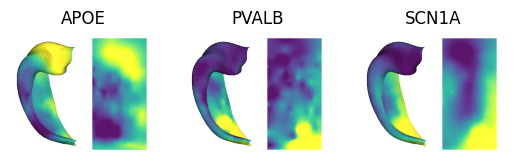

In [4]:
# Example genes:
genes = ["APOE", "PVALB", "SCN1A"]

fig, ax = plt.subplots(1,3)
for  i, g in enumerate(genes):
    cdata = expression[g].values
    hm.plotting.surfplot_canonical_foldunfold(cdata, cmap="viridis", hemis=['L'], labels=['hipp'],
                                              unfoldAPrescale=True, share='row', tighten_cwindow=True, 
                                              screenshot=True, filename=f'tmp_{g}.png')
    f = plt.imread(f'tmp_{g}.png')
    ax[i].imshow(f)
    ax[i].set_axis_off()
    ax[i].set_anchor("NW")
    ax[i].set_title(g)
    
!rm tmp*.png

**2 - Compute gradients**

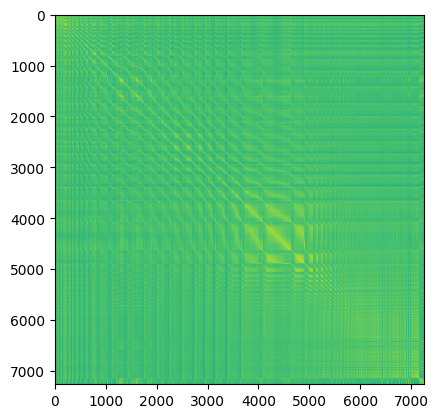

In [5]:
# Affinity matrix (similarity between region-wise expression profiles):
affinity = compute_affinity(expression.values, kernel="normalized_angle")

plt.imshow(affinity, cmap="viridis", clim=(0,1))

In [6]:
# Diffusion map embedding:
gm = GradientMaps(n_components=10, kernel="normalized_angle", approach="dm")
gm = gm.fit(expression.values, sparsity=0.9)

<BarContainer object of 10 artists>

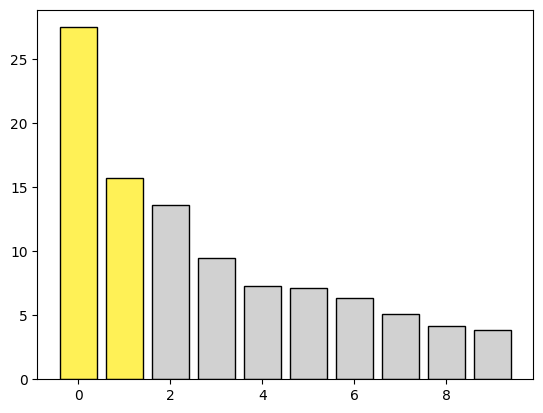

In [7]:
# Scaled eigenvalues:
total_lambda = np.sum(gm.lambdas_)
lambda_ratios = gm.lambdas_ / total_lambda * 100

color = ["#FFF156"] * 2 + ["#D1D1D1"] * 8 # Highlight the first two gradients, which explain the most variance in the data
plt.bar(range(10), lambda_ratios, color=color, edgecolor="k")

/Users/alexngo/Repositories/toolboxes/hippogenes/.conda/lib/python3.9/site-packages/brainspace/plotting/surface_plotting.py:437: RuntimeWarning: Running plot_hemispheres without a display may result in a crash. For a workaround please consult https://github.com/MICA-MNI/BrainSpace/issues/66. To suppress this warning set suppress_warnings=True.
  warnings.warn(


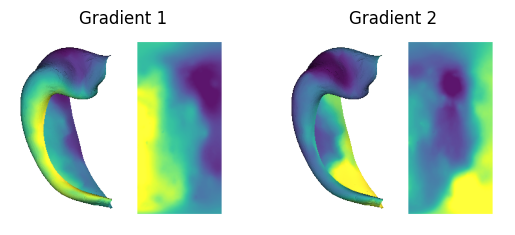

In [8]:
# First two eigenvectors:
fig, ax = plt.subplots(1, 2)
for  i in range(2):
    cdata = gm.gradients_[:, i]
    clim = (np.percentile(cdata, 5), np.percentile(cdata, 95))
    hm.plotting.surfplot_canonical_foldunfold(cdata, cmap="viridis", color_range=clim, hemis=['L'], 
                                              labels=['hipp'], unfoldAPrescale=True, share='row', 
                                              tighten_cwindow=True, screenshot=True, filename=f'tmp_{i}.png')
    f = plt.imread(f'tmp_{i}.png')
    ax[i].imshow(f)
    ax[i].set_axis_off()
    ax[i].set_anchor("NW")
    ax[i].set_title(f"Gradient {i+1}")
    
!rm tmp*.png

**3 - Neuroanatomical stratification**

In [ ]:
def plot_ridgeplot(data, cmap='viridis', color_range=None):
    
    # Initialize figure and axes for ridge plot
    f, axs = plt.subplots(nrows=matrix.shape[0], figsize=(3.468504*2.5, 2.220472*3.5), sharex=True, sharey=True)
    f.set_facecolor('none')
    
    x = np.linspace(Range[0], Range[1], 100)  # Define x-axis range
    
    for i, ax in enumerate(axs, 1):
        # Plot density estimation
        sns.kdeplot(df[df["subject"]==str(i)]['feature'],
                    fill=True,
                    color="w",
                    alpha=0.25,
                    linewidth=1.5,
                    legend=False,
                    ax=ax)
        
        ax.set_xlim(Range[0], Range[1])
        
        # Overlay colormap
        im = ax.imshow(np.vstack([x, x]),
                       cmap=Cmap,
                       aspect="auto",
                       extent=[*ax.get_xlim(), *ax.get_ylim()]
                      )
        
        # Clip colormap to density shape
        path = ax.collections[0].get_paths()[0]
        patch = mpl.patches.PathPatch(path, transform=ax.transData)
        im.set_clip_path(patch)
        
        # Remove unnecessary plot borders
        ax.spines[['left','right','bottom','top']].set_visible(False)
        
        # Hide x-axis ticks except for the last plot
        if i != matrix.shape[0]:
            ax.tick_params(axis="x", length=0)
        else:
            ax.set_xlabel(Xlab)
        
        ax.set_yticks([])
        ax.set_ylabel("")
        ax.axhline(0, color="black")
        ax.set_facecolor("none")
    
    # Add subject labels to the left side of each plot
    for i, ax in enumerate(axs):
        if i == matrix.shape[0] - 1:
            ax.set_xticks([Range[0], Range[1]])  # Set x-axis ticks for the bottom plot
        else:
            ax.set_xticks([])  # Remove x-axis ticks from other plots
        ax.text(0.05, 0.01, matrix_df[i], transform=ax.transAxes, fontsize=10, color='black', ha='left', va='bottom')
    
    plt.subplots_adjust(hspace=-0.8)  # Adjust spacing between plots
    
    # Add title if provided
    if title:
        plt.suptitle(title, y=0.99, fontsize=16)
    
    # Save or display the plot
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    else:
        plt.show()

[Text(0, 0.5, ''), []]

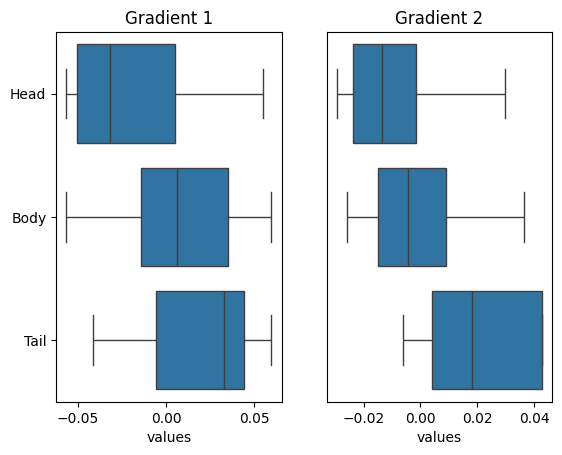

In [49]:
# Head/body/tail:
hm_path = os.path.dirname(hm.__file__)

surface = read_surface(os.path.join(hm_path, "resources", "canonical_surfs", "tpl-avg_space-unfold_den-0p5mm_label-hipp_midthickness.surf.gii"))
coords = surface.Points[:,0]

coords_min, coords_max = np.min(coords), np.max(coords)
coords_range = coords_max - coords_min
coords_thirds = [coords_min + coords_range / 3, coords_min + 2 * coords_range / 3]

label = np.empty(coords.shape[0], dtype=object)
label[coords > coords_thirds[0]] = "Head"
label[coords < coords_thirds[1]] = "Tail"
label[(coords >= coords_thirds[0]) & (coords <= coords_thirds[1])] = "Body"

fig, ax = plt.subplots(1, 2)
for i in range(2):
    df = pd.DataFrame({
        "values": gm.gradients_[:, i],
        "label": label
    }).sort_values("label")
    
    sns.boxplot(x=df["values"], y=df["label"], ax=ax[i], order=["Head", "Body", "Tail"], fliersize=0)
    ax[i].set_title(f"Gradient {i+1}")
ax[0].set(ylabel=None)
ax[1].set(ylabel=None, yticks=[])



[Text(0, 0.5, ''), []]

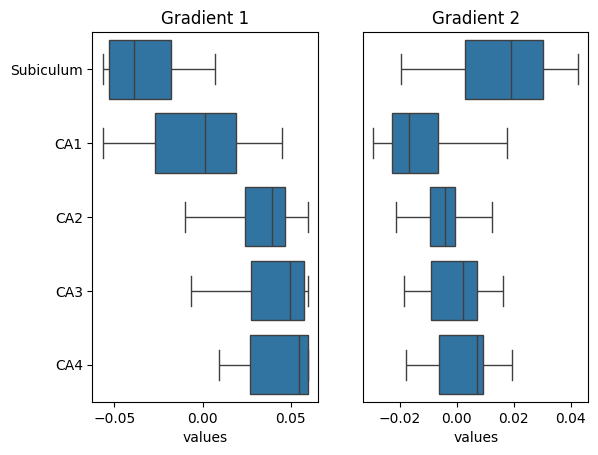

In [53]:
# Subfield:
hm_path = os.path.dirname(hm.__file__)
subfields = nib.load(os.path.join(hm_path, "resources", "parc-multihist7", "sub-0_hemi-0_space-0_den-0p5mm_label-hipp_atlas-multihist7_subfields.label.gii")).darrays[0].data
subfield_labels = {1: "Subiculum", 2: "CA1", 3: "CA2", 4: "CA3", 5: "CA4"}

label = np.empty(coords.shape[0], dtype=object)
for i in subfield_labels.keys():
    label[subfields == i] = subfield_labels[i]
    
fig, ax = plt.subplots(1, 2)
for i in range(2):
    df = pd.DataFrame({
        "values": gm.gradients_[:, i],
        "label": label
    }).sort_values("label")
    
    sns.boxplot(x=df["values"], y=df["label"], ax=ax[i], order=["Subiculum", "CA1", "CA2", "CA3", "CA4"], fliersize=0)
    ax[i].set_title(f"Gradient {i+1}")
ax[0].set(ylabel=None)
ax[1].set(ylabel=None, yticks=[])